# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words

df = pd.read_csv(r'C:\Users\spoll\Desktop\Full Sail\Data Viz\Data_Visualization_And_Modeling_Online\Lab\IMDB_Dataset_Cleaned.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend o...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


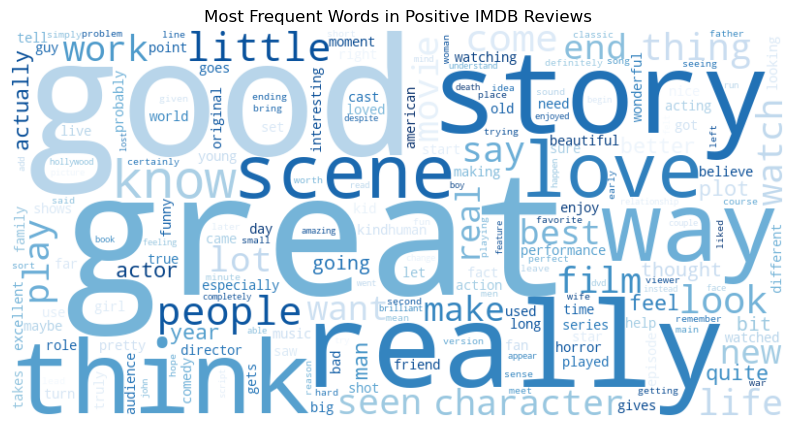

In [8]:
positive_reviews = ' '.join(df[df['sentiment'] == 'positive']['review'].astype(str))

positive_words = positive_reviews.lower().split()
positive_words = [word.strip(string.punctuation) for word in positive_words 
                  if word.isalnum() 
                  and word not in sklearn_stop_words 
                  and len(word) > 2]

wordcloud1 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(' '.join(positive_words))
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud1, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive IMDB Reviews')
plt.show()

## Visualization 1: Positive Review Word Cloud
This word cloud shows the most frequently used words in positive IMDB movie reviews. 
Words like "film", "movie", "story", and "character" dominate, suggesting that 
positive reviewers focus on storytelling and character development when praising a film.

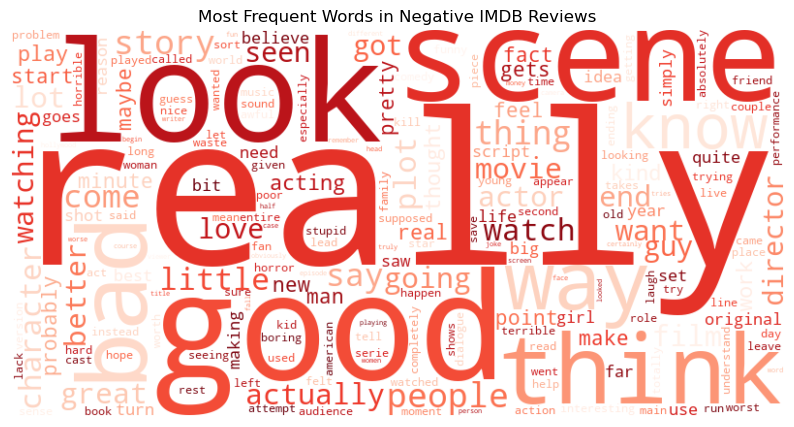

In [13]:
negative_reviews = ' '.join(df[df['sentiment'] == 'negative']['review'].astype(str))

negative_words = negative_reviews.lower().split()
negative_words = [word.strip(string.punctuation) for word in negative_words 
                  if word.isalnum() 
                  and word not in sklearn_stop_words 
                  and len(word) > 2]

wordcloud2 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(' '.join(negative_words))
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud2, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative IMDB Reviews')
plt.show()

## Visualization 2: Negative Review Word Cloud
This word cloud shows the most frequently used words in negative IMDB movie reviews.
Similar words appear as in positive reviews, but words like "bad", "worst", and 
"boring" are more prominent, indicating that negative reviewers focus on poor 
plot execution and lack of entertainment value.

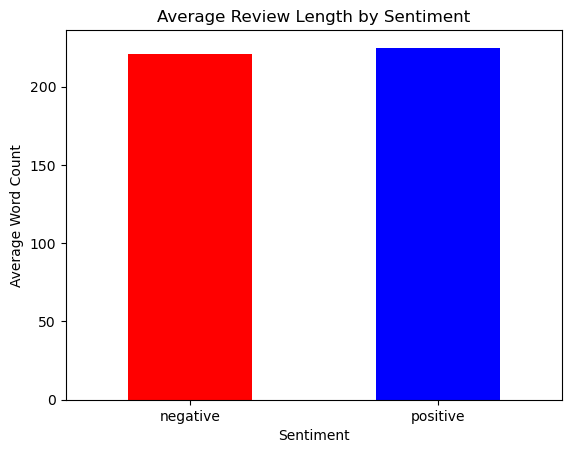

In [21]:
df['review_length'] = df['review'].str.split().str.len()

df.groupby('sentiment')['review_length'].mean().plot(kind='bar', color=['red', 'blue'])
plt.title('Average Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Word Count')
plt.xticks(rotation=0)
plt.show()

## Visualization 3: Review Length by Sentiment
This bar chart compares the average word count of positive vs negative IMDB reviews.
This helps us understand whether reviewers tend to write more when they are expressing positive or negative opinions about a film, which can reveal patterns in how people communicate their movie experiences.